# IDMC extract

In [43]:
# Token
API_TOKEN = "XZ0GDDKZ2RQMCGZG"

In [8]:
# imports
import requests
import geopandas as gpd
# import MultiPoint
from shapely.geometry import MultiPoint, Point
import folium
from folium.plugins import MarkerCluster
import pandas as pd

import ast

## Disagregated data

In [52]:
# requests API
url = "https://helix-tools-api.idmcdb.org/external-api/gidd/disaggregations/disaggregation-geojson/"
params = {
    "client_id": API_TOKEN,
    'limit': 20,
}
response = requests.get(url, params=params, timeout=120)
print(response.status_code)
data = response.json()

200


In [53]:
gdf_raw = gpd.GeoDataFrame.from_features(data["features"])

In [9]:
gdf_raw.columns

NameError: name 'gdf_raw' is not defined

In [55]:
# print
print('Hazard category:', gdf_raw['Hazard category'].unique())
print("\n")
print('Hazard sub category:', gdf_raw["Hazard sub category"].unique())
print("\n")
print('Hazard type:', gdf_raw["Hazard type"].unique())
print("\n")
print("Figure cause:", gdf_raw["Figure cause"].unique())


Hazard category: [nan 'Weather related' 'Mixed disasters' 'Geophysical']


Hazard sub category: [nan 'Hydrological' 'Meteorological' 'Mixed disasters' 'Climatological'
 'Geophysical']


Hazard type: [nan 'Flood' 'Mass Movement' 'Extreme Temperature' 'Mixed disasters'
 'Storm' 'Wildfire' 'Earthquake' 'Erosion' 'Drought' 'Wave action'
 'Volcanic activity' 'Sea level Rise']


Figure cause: ['Conflict' 'Disaster']


In [93]:
# save data to parquet
path_parquet = "../data/parquet/gd_disagregated_full.parquet"
gdf_raw.to_parquet(path_parquet)

In [10]:
# load data from parquet
path_parquet = "../data/parquet/gd_disagregated_full.parquet"
gdf = gpd.read_parquet(path_parquet)

In [5]:
# print statistics of the data and the shape, and example of the rows
print("Shape of the data:", gdf.shape)
print("\n")
print("Data types of the columns:\n", gdf.dtypes)
print("\n")


Shape of the data: (27409, 41)


Data types of the columns:
 geometry                     geometry
ID                              int64
ISO3                           object
Country                        object
Geographical region            object
Figure cause                   object
Year                            int64
Figure category                object
Figure unit                    object
Reported figures                int64
Total figures                   int64
Violence type                  object
Stock date                     object
Stock date accuracy            object
Stock reporting date           object
Publishers                     object
Sources                        object
Sources type                   object
Event ID                        int64
Event name                     object
Event cause                    object
Event main trigger             object
Event start date               object
Event end date                 object
Event start date accuracy  

In [11]:
gdf.head()

,geometry,ID,ISO3,Country,Geographical region,Figure cause,Year,Figure category,Figure unit,Reported figures,...,Displacement occurred,Start date,Start date accuracy,End date,End date accuracy,Hazard category,Hazard sub category,Hazard type,Hazard sub type,Household size
0,MULTIPOINT (28.46257 9.46809),143576,AB9,Abyei Area,Sub-Saharan Africa,Conflict,2024,IDPs,Person,8053,...,Displacement without preventive evacuations re...,None,None,None,None,None,None,None,None,NaN
1,MULTIPOINT (28.46257 9.46809),143577,AB9,Abyei Area,Sub-Saharan Africa,Conflict,2024,IDPs,Person,34160,...,Displacement without preventive evacuations re...,None,None,None,None,None,None,None,None,NaN
2,MULTIPOINT (28.46257 9.46809),144413,AB9,Abyei Area,Sub-Saharan Africa,Conflict,2024,Internal Displacements,Person,20000,...,Displacement without preventive evacuations re...,2024-02-01,Month,2024-02-29,Month,None,None,None,None,NaN
3,MULTIPOINT (28.46257 9.46809),168443,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,1650,...,Displacement without preventive evacuations re...,2024-08-01,Month,2024-08-31,Month,Weather related,Hydrological,Flood,Flood,NaN
4,MULTIPOINT (28.46257 9.46809),168453,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,11930,...,Displacement without preventive evacuations re...,2024-09-01,Month,2024-09-30,Month,Weather related,Hydrological,Flood,Flood,NaN


In [12]:
print(gdf.columns.tolist())

['geometry', 'ID', 'ISO3', 'Country', 'Geographical region', 'Figure cause', 'Year', 'Figure category', 'Figure unit', 'Reported figures', 'Total figures', 'Violence type', 'Stock date', 'Stock date accuracy', 'Stock reporting date', 'Publishers', 'Sources', 'Sources type', 'Event ID', 'Event name', 'Event cause', 'Event main trigger', 'Event start date', 'Event end date', 'Event start date accuracy', 'Event end date accuracy', 'Is housing destruction', 'Event codes (Code:Type)', 'Locations name', 'Locations accuracy', 'Locations type', 'Displacement occurred', 'Start date', 'Start date accuracy', 'End date', 'End date accuracy', 'Hazard category', 'Hazard sub category', 'Hazard type', 'Hazard sub type', 'Household size']


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Check accuracy columns
print("Event start date accuracy unique values:")
print(gdf['Event start date accuracy'].unique())
print("\nEvent end date accuracy unique values:")
print(gdf['Event end date accuracy'].unique())
print("\nStart date accuracy unique values:")
print(gdf['Start date accuracy'].unique())
print("\nEnd date accuracy unique values:")
print(gdf['End date accuracy'].unique())

Event start date accuracy unique values:
['Day' None 'Month' 'Week' 'Year']

Event end date accuracy unique values:
['Day' None 'Month' 'Week' 'Year']

Start date accuracy unique values:
[None 'Month' 'Day' 'Week' 'Year']

End date accuracy unique values:
[None 'Month' 'Day' 'Week' 'Year']


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_35822/2987842454.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax9.boxplot(data_to_plot, labels=accuracy_levels, patch_artist=True)


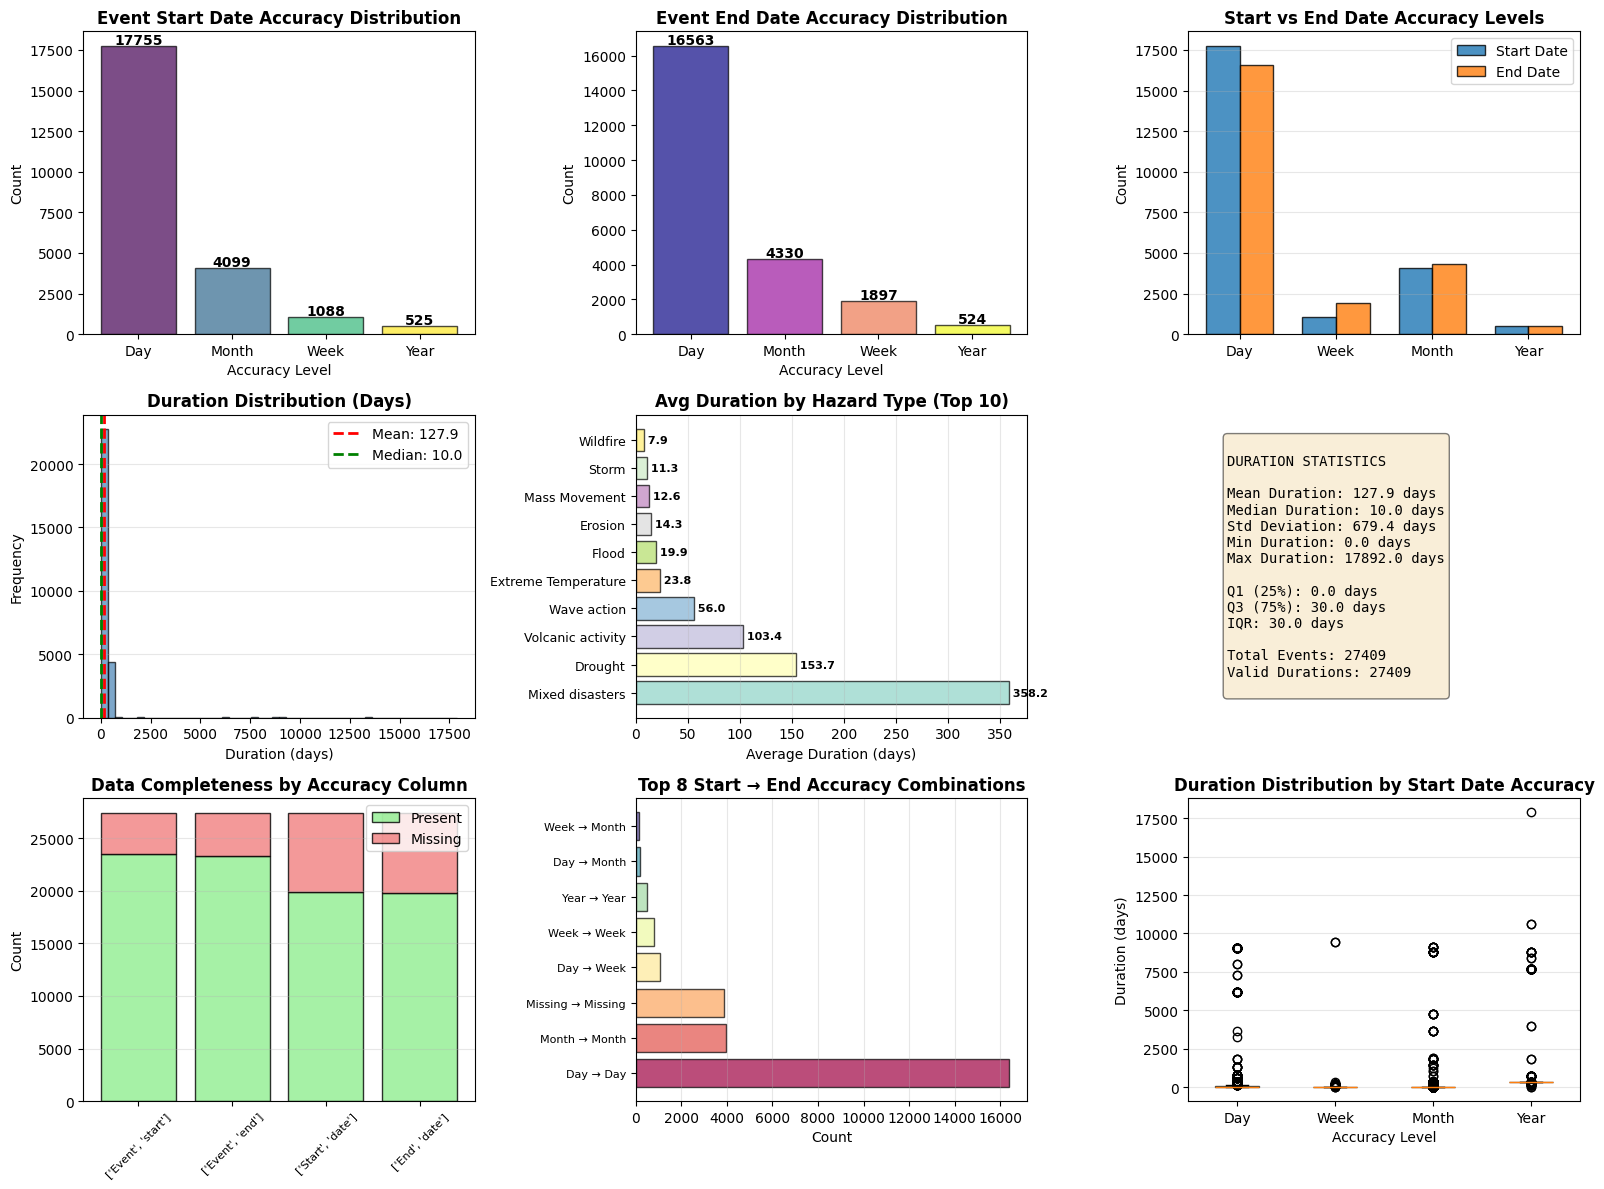

✓ Plots saved as 'Dates_and_Accuracy_Stats.png'


In [15]:
# Calculate duration for each event
gdf['Event start date'] = pd.to_datetime(gdf['Event start date'], errors='coerce')
gdf['Event end date'] = pd.to_datetime(gdf['Event end date'], errors='coerce')
gdf['duration_days'] = (gdf['Event end date'] - gdf['Event start date']).dt.days

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Event Start Date Accuracy Distribution
ax1 = plt.subplot(3, 3, 1)
start_acc_counts = gdf['Event start date accuracy'].value_counts()
colors1 = plt.cm.viridis(np.linspace(0, 1, len(start_acc_counts)))
ax1.bar(start_acc_counts.index, start_acc_counts.values, color=colors1, edgecolor='black', alpha=0.7)
ax1.set_title('Event Start Date Accuracy Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10)
ax1.set_xlabel('Accuracy Level', fontsize=10)
for i, v in enumerate(start_acc_counts.values):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Event End Date Accuracy Distribution
ax2 = plt.subplot(3, 3, 2)
end_acc_counts = gdf['Event end date accuracy'].value_counts()
colors2 = plt.cm.plasma(np.linspace(0, 1, len(end_acc_counts)))
ax2.bar(end_acc_counts.index, end_acc_counts.values, color=colors2, edgecolor='black', alpha=0.7)
ax2.set_title('Event End Date Accuracy Distribution', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=10)
ax2.set_xlabel('Accuracy Level', fontsize=10)
for i, v in enumerate(end_acc_counts.values):
    ax2.text(i, v + 100, str(v), ha='center', fontweight='bold')

# 3. Accuracy Level Comparison (combining start and end)
ax3 = plt.subplot(3, 3, 3)
accuracy_levels = ['Day', 'Week', 'Month', 'Year']
start_acc_by_level = [gdf[gdf['Event start date accuracy'] == level].shape[0] for level in accuracy_levels]
end_acc_by_level = [gdf[gdf['Event end date accuracy'] == level].shape[0] for level in accuracy_levels]
x = np.arange(len(accuracy_levels))
width = 0.35
ax3.bar(x - width/2, start_acc_by_level, width, label='Start Date', alpha=0.8, edgecolor='black')
ax3.bar(x + width/2, end_acc_by_level, width, label='End Date', alpha=0.8, edgecolor='black')
ax3.set_title('Start vs End Date Accuracy Levels', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=10)
ax3.set_xticks(x)
ax3.set_xticklabels(accuracy_levels)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Duration Distribution (in days)
ax4 = plt.subplot(3, 3, 4)
valid_durations = gdf[gdf['duration_days'] >= 0]['duration_days']
ax4.hist(valid_durations, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax4.set_title('Duration Distribution (Days)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=10)
ax4.set_xlabel('Duration (days)', fontsize=10)
ax4.axvline(valid_durations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {valid_durations.mean():.1f}')
ax4.axvline(valid_durations.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {valid_durations.median():.1f}')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. Average Duration by Hazard Type
ax5 = plt.subplot(3, 3, 5)
avg_duration_by_type = gdf.groupby('Hazard type')['duration_days'].mean().sort_values(ascending=False).head(10)
colors5 = plt.cm.Set3(np.linspace(0, 1, len(avg_duration_by_type)))
ax5.barh(range(len(avg_duration_by_type)), avg_duration_by_type.values, color=colors5, edgecolor='black', alpha=0.7)
ax5.set_yticks(range(len(avg_duration_by_type)))
ax5.set_yticklabels(avg_duration_by_type.index, fontsize=9)
ax5.set_title('Avg Duration by Hazard Type (Top 10)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Average Duration (days)', fontsize=10)
ax5.grid(axis='x', alpha=0.3)
for i, v in enumerate(avg_duration_by_type.values):
    ax5.text(v, i, f' {v:.1f}', va='center', fontweight='bold', fontsize=8)

# 6. Duration Statistics
ax6 = plt.subplot(3, 3, 6)
ax6.axis('off')
stats_text = f"""
DURATION STATISTICS

Mean Duration: {valid_durations.mean():.1f} days
Median Duration: {valid_durations.median():.1f} days
Std Deviation: {valid_durations.std():.1f} days
Min Duration: {valid_durations.min():.1f} days
Max Duration: {valid_durations.max():.1f} days

Q1 (25%): {valid_durations.quantile(0.25):.1f} days
Q3 (75%): {valid_durations.quantile(0.75):.1f} days
IQR: {valid_durations.quantile(0.75) - valid_durations.quantile(0.25):.1f} days

Total Events: {len(gdf)}
Valid Durations: {len(valid_durations)}
"""
ax6.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center', 
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 7. Missing Data by Accuracy Column
ax7 = plt.subplot(3, 3, 7)
accuracy_cols = ['Event start date accuracy', 'Event end date accuracy', 'Start date accuracy', 'End date accuracy']
missing_counts = [gdf[col].isna().sum() for col in accuracy_cols]
present_counts = [gdf[col].notna().sum() for col in accuracy_cols]
x = np.arange(len(accuracy_cols))
ax7.bar(x, present_counts, label='Present', alpha=0.8, edgecolor='black', color='lightgreen')
ax7.bar(x, missing_counts, bottom=present_counts, label='Missing', alpha=0.8, edgecolor='black', color='lightcoral')
ax7.set_title('Data Completeness by Accuracy Column', fontsize=12, fontweight='bold')
ax7.set_ylabel('Count', fontsize=10)
ax7.set_xticks(x)
ax7.set_xticklabels([col.split(' ')[0:2] for col in accuracy_cols], fontsize=8, rotation=45)
ax7.legend()
ax7.grid(axis='y', alpha=0.3)

# 8. Event Count by Accuracy Combination
ax8 = plt.subplot(3, 3, 8)
accuracy_combo = (gdf['Event start date accuracy'].fillna('Missing') + ' → ' + 
                  gdf['Event end date accuracy'].fillna('Missing'))
top_combos = accuracy_combo.value_counts().head(8)
colors8 = plt.cm.Spectral(np.linspace(0, 1, len(top_combos)))
ax8.barh(range(len(top_combos)), top_combos.values, color=colors8, edgecolor='black', alpha=0.7)
ax8.set_yticks(range(len(top_combos)))
ax8.set_yticklabels([c[:20] + '...' if len(c) > 20 else c for c in top_combos.index], fontsize=8)
ax8.set_title('Top 8 Start → End Accuracy Combinations', fontsize=12, fontweight='bold')
ax8.set_xlabel('Count', fontsize=10)
ax8.grid(axis='x', alpha=0.3)

# 9. Duration Box Plot by Accuracy Level
ax9 = plt.subplot(3, 3, 9)
data_to_plot = [gdf[gdf['Event start date accuracy'] == level]['duration_days'].dropna() 
                for level in accuracy_levels]
bp = ax9.boxplot(data_to_plot, labels=accuracy_levels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(accuracy_levels)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax9.set_title('Duration Distribution by Start Date Accuracy', fontsize=12, fontweight='bold')
ax9.set_ylabel('Duration (days)', fontsize=10)
ax9.set_xlabel('Accuracy Level', fontsize=10)
ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../Dates_and_Accuracy_Stats.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plots saved as 'Dates_and_Accuracy_Stats.png'")

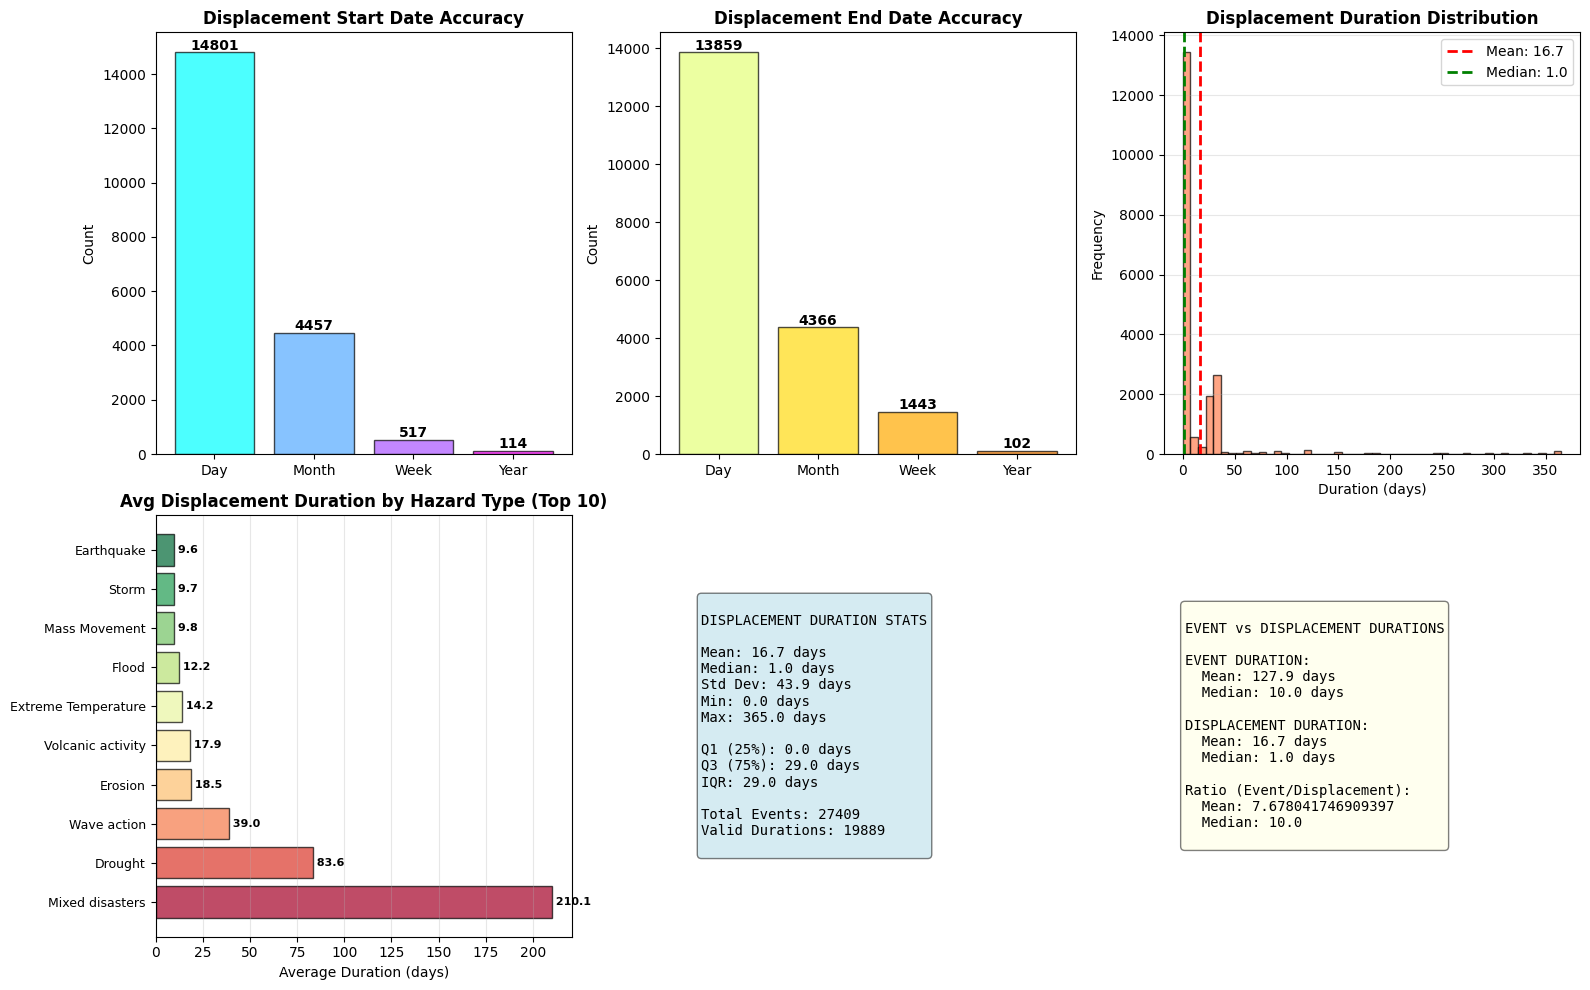

✓ Displacement date plots saved as 'Displacement_Dates_and_Accuracy_Stats.png'


In [17]:
# Additional plots for Displacement Dates (Start/End date columns)
gdf['Start date'] = pd.to_datetime(gdf['Start date'], errors='coerce')
gdf['End date'] = pd.to_datetime(gdf['End date'], errors='coerce')
gdf['displacement_duration_days'] = (gdf['End date'] - gdf['Start date']).dt.days

fig2 = plt.figure(figsize=(16, 10))

# 1. Displacement Start Date Accuracy
ax1 = plt.subplot(2, 3, 1)
disp_start_acc = gdf['Start date accuracy'].value_counts()
colors1 = plt.cm.cool(np.linspace(0, 1, len(disp_start_acc)))
ax1.bar(disp_start_acc.index, disp_start_acc.values, color=colors1, edgecolor='black', alpha=0.7)
ax1.set_title('Displacement Start Date Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10)
for i, v in enumerate(disp_start_acc.values):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Displacement End Date Accuracy
ax2 = plt.subplot(2, 3, 2)
disp_end_acc = gdf['End date accuracy'].value_counts()
colors2 = plt.cm.Wistia(np.linspace(0, 1, len(disp_end_acc)))
ax2.bar(disp_end_acc.index, disp_end_acc.values, color=colors2, edgecolor='black', alpha=0.7)
ax2.set_title('Displacement End Date Accuracy', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=10)
for i, v in enumerate(disp_end_acc.values):
    ax2.text(i, v + 100, str(v), ha='center', fontweight='bold')

# 3. Displacement Duration Distribution
ax3 = plt.subplot(2, 3, 3)
valid_disp_durations = gdf[gdf['displacement_duration_days'] >= 0]['displacement_duration_days']
ax3.hist(valid_disp_durations, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_title('Displacement Duration Distribution', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_xlabel('Duration (days)', fontsize=10)
if len(valid_disp_durations) > 0:
    ax3.axvline(valid_disp_durations.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {valid_disp_durations.mean():.1f}')
    ax3.axvline(valid_disp_durations.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {valid_disp_durations.median():.1f}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Average Displacement Duration by Hazard Type
ax4 = plt.subplot(2, 3, 4)
avg_disp_duration_by_type = gdf.groupby('Hazard type')['displacement_duration_days'].mean().sort_values(ascending=False).head(10)
if len(avg_disp_duration_by_type) > 0:
    colors4 = plt.cm.RdYlGn(np.linspace(0, 1, len(avg_disp_duration_by_type)))
    ax4.barh(range(len(avg_disp_duration_by_type)), avg_disp_duration_by_type.values, 
             color=colors4, edgecolor='black', alpha=0.7)
    ax4.set_yticks(range(len(avg_disp_duration_by_type)))
    ax4.set_yticklabels(avg_disp_duration_by_type.index, fontsize=9)
    ax4.set_title('Avg Displacement Duration by Hazard Type (Top 10)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Average Duration (days)', fontsize=10)
    ax4.grid(axis='x', alpha=0.3)
    for i, v in enumerate(avg_disp_duration_by_type.values):
        ax4.text(v, i, f' {v:.1f}', va='center', fontweight='bold', fontsize=8)

# 5. Displacement Duration Statistics
ax5 = plt.subplot(2, 3, 5)
ax5.axis('off')
if len(valid_disp_durations) > 0:
    stats_text2 = f"""
DISPLACEMENT DURATION STATS

Mean: {valid_disp_durations.mean():.1f} days
Median: {valid_disp_durations.median():.1f} days
Std Dev: {valid_disp_durations.std():.1f} days
Min: {valid_disp_durations.min():.1f} days
Max: {valid_disp_durations.max():.1f} days

Q1 (25%): {valid_disp_durations.quantile(0.25):.1f} days
Q3 (75%): {valid_disp_durations.quantile(0.75):.1f} days
IQR: {valid_disp_durations.quantile(0.75) - valid_disp_durations.quantile(0.25):.1f} days

Total Events: {len(gdf)}
Valid Durations: {len(valid_disp_durations)}
"""
else:
    stats_text2 = "No valid displacement durations"
ax5.text(0.1, 0.5, stats_text2, fontsize=10, verticalalignment='center', 
         family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 6. Comparison: Event vs Displacement Duration Statistics
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
comparison_text = f"""
EVENT vs DISPLACEMENT DURATIONS

EVENT DURATION:
  Mean: {valid_durations.mean():.1f} days
  Median: {valid_durations.median():.1f} days

DISPLACEMENT DURATION:
  Mean: {valid_disp_durations.mean():.1f} days
  Median: {valid_disp_durations.median():.1f} days

Ratio (Event/Displacement):
  Mean: {valid_durations.mean() / valid_disp_durations.mean() if valid_disp_durations.mean() > 0 else 'N/A'}
  Median: {valid_durations.median() / valid_disp_durations.median() if valid_disp_durations.median() > 0 else 'N/A'}
"""
ax6.text(0.05, 0.5, comparison_text, fontsize=10, verticalalignment='center', 
         family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('../Displacement_Dates_and_Accuracy_Stats.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Displacement date plots saved as 'Displacement_Dates_and_Accuracy_Stats.png'")

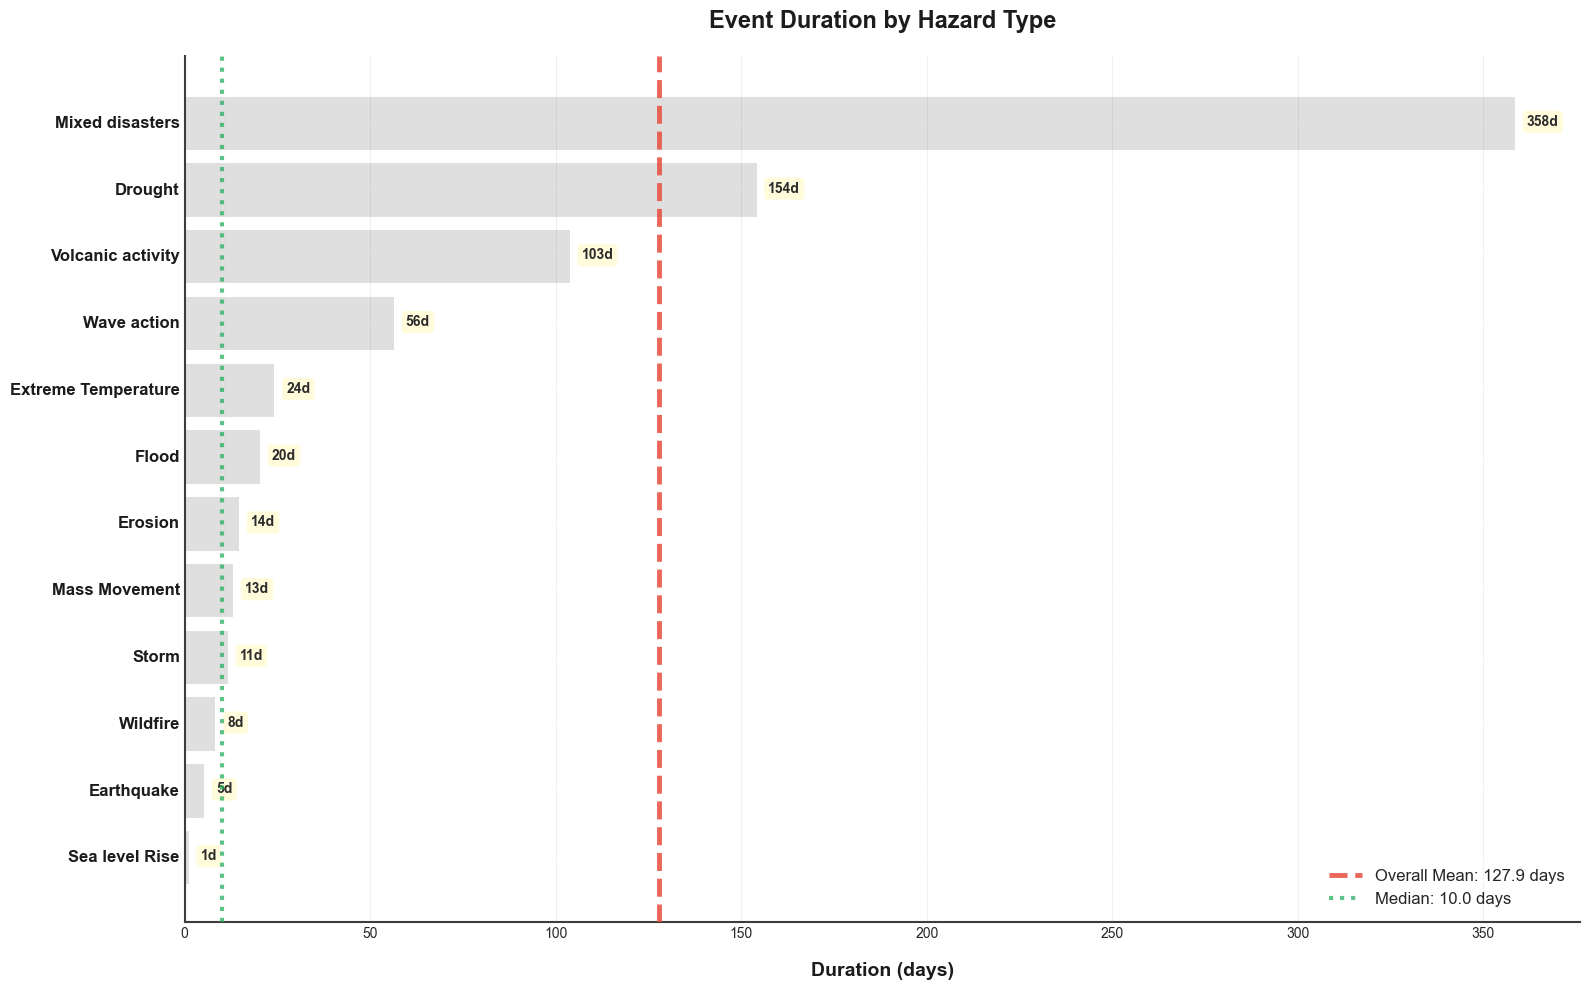

✓ Enhanced plots saved:
  - Duration_by_Hazard_Type_Enhanced.png (PNG, 300 DPI)
  - Duration_by_Hazard_Type_Enhanced.pdf (PDF, 300 DPI)


In [20]:
# Enhanced nature-style plot: Duration by Hazard Type with Overall Average
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects

# Prepare data
avg_by_type = gdf.groupby('Hazard type')['duration_days'].mean().sort_values(ascending=True)
overall_avg = gdf['duration_days'].mean()
median_val = gdf['duration_days'].median()

# Set up professional style with white background
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#FFFFFF'

# Create figure with clean layout
fig, ax1 = plt.subplots(figsize=(16, 10))

# Enhanced nature color palette with gradient (earth to forest)
nature_gradient = ['#D4A574', '#C99A6C', '#BE9064', '#B3865C', '#A87C54',
                   '#9D7250', '#926848', '#875E40', '#7C5438', '#714A30',
                   '#6A4126', '#63381D', '#5C3414', '#52300D', '#482C0B']

# Extend if needed
while len(nature_gradient) < len(avg_by_type):
    nature_gradient.extend(nature_gradient)
colors = nature_gradient[:len(avg_by_type)]

# ============== MAIN BAR PLOT ==============
bars = ax1.barh(range(len(avg_by_type)), avg_by_type.values, 
                 color=colors, edgecolor='#2C2C2C', linewidth=2, alpha=0.90)

# Add soft shadow effect to bars
for bar in bars:
    bar.set_path_effects([path_effects.SimplePatchShadow(offset=(1, -1), shadow_rgbFace='#2C2C2C', alpha=0.15)])

# Add overall average line with enhanced styling
ax1.axvline(overall_avg, color='#E74C3C', linestyle='--', linewidth=3.5, 
            label=f'Overall Mean: {overall_avg:.1f} days', zorder=5, alpha=0.85)
ax1.axvline(median_val, color='#27AE60', linestyle=':', linewidth=3, 
            label=f'Median: {median_val:.1f} days', zorder=4, alpha=0.75)

# Enhanced styling
ax1.set_yticks(range(len(avg_by_type)))
ax1.set_yticklabels(avg_by_type.index, fontsize=12, fontweight='600', color='#1C1C1C')
ax1.set_xlabel('Duration (days)', fontsize=14, fontweight='bold', color='#1C1C1C', labelpad=15)
ax1.set_title('Event Duration by Hazard Type', 
              fontsize=17, fontweight='bold', color='#1C1C1C', pad=20, family='sans-serif')

# Grid styling
ax1.grid(axis='x', alpha=0.25, linestyle='-', linewidth=0.7, color='#BFBFBF')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#3D3D3D')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_color('#3D3D3D')
ax1.spines['bottom'].set_linewidth(1.5)

# Add value labels with better formatting
for i, (idx, val) in enumerate(avg_by_type.items()):
    ax1.text(val + max(avg_by_type.values) * 0.01, i, f'{val:.0f}d', 
             va='center', fontsize=10, fontweight='700', color='#2C2C2C',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFACD', alpha=0.7, edgecolor='none'))

# Enhanced legend
legend = ax1.legend(loc='lower right', fontsize=12, framealpha=0.95, 
                    edgecolor='#3D3D3D', fancybox=True, shadow=True)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()

# Save as both PNG and PDF with high quality
plt.savefig('../Duration_by_Hazard_Type_Enhanced.png', dpi=300, bbox_inches='tight', 
            facecolor='#FFFFFF', edgecolor='none', format='png')
plt.savefig('../Duration_by_Hazard_Type_Enhanced.pdf', dpi=300, bbox_inches='tight', 
            facecolor='#FFFFFF', edgecolor='none', format='pdf')
plt.show()

print("✓ Enhanced plots saved:")
print("  - Duration_by_Hazard_Type_Enhanced.png (PNG, 300 DPI)")
print("  - Duration_by_Hazard_Type_Enhanced.pdf (PDF, 300 DPI)")

In [ ]:
# plot stuff about the date columns

In [95]:
len(gdf)

27409

In [96]:
# remove entry that has no figures (Total figures = 0) or has no date (Event start date = NaN) and (Event end date = NaN)
gdf = gdf_raw[
    (gdf_raw["Total figures"] > 0)
    & (gdf_raw["Event start date"].notna())
    & (gdf_raw["Event end date"].notna())
    # & (gdf_raw["Hazard type"].notna())
]

In [97]:
len(gdf)

25760

In [98]:
# check rows that has more than one point in geometry
gdf["geometry"].apply(lambda x: len(x.geoms) if hasattr(x, 'geoms') else 1).value_counts()

# What this means is that some rows have multiple geometries (e.g., polygons with holes or multipolygons).
# We need to make into one point

geometry
1     22900
2      1957
3       429
4       161
5        96
6        60
7        38
8        32
11       23
10       15
12       13
9         9
16        4
14        4
15        3
13        3
24        3
19        3
17        3
22        1
28        1
21        1
23        1
Name: count, dtype: int64

In [99]:
# print geometry of entry 16
print(gdf.iloc[16].geometry)

MULTIPOINT (73.347519 36.967209, 63.580769 35.275101, 68.667297 36.820259, 71.119164 35.472191, 66.09034 35.720829, 66.910362 36.535252, 64.786491 36.226768, 64.580551 34.198509, 66.419472 32.992851, 67.022903 32.28857, 70.380028 34.22039)


In [100]:
# compute the centroid of all entry
gdf["geometry"] = gdf["geometry"].apply(lambda x: x.centroid if hasattr(x, 'centroid') else x)

/Users/su28355962/Documents/codes/migration-estimation/.venv/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [101]:
# set geometry as index and epsg as 4326
gdf = gdf.set_geometry("geometry", crs="EPSG:4326")

In [102]:
gdf

,geometry,ID,ISO3,Country,Geographical region,Figure cause,Year,Figure category,Figure unit,Reported figures,...,Displacement occurred,Start date,Start date accuracy,End date,End date accuracy,Hazard category,Hazard sub category,Hazard type,Hazard sub type,Household size
0,POINT (28.46257 9.46809),143576,AB9,Abyei Area,Sub-Saharan Africa,Conflict,2024,IDPs,Person,8053,...,Displacement without preventive evacuations re...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POINT (28.46257 9.46809),143577,AB9,Abyei Area,Sub-Saharan Africa,Conflict,2024,IDPs,Person,34160,...,Displacement without preventive evacuations re...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POINT (28.46257 9.46809),144413,AB9,Abyei Area,Sub-Saharan Africa,Conflict,2024,Internal Displacements,Person,20000,...,Displacement without preventive evacuations re...,2024-02-01,Month,2024-02-29,Month,NaN,NaN,NaN,NaN,NaN
3,POINT (28.46257 9.46809),168443,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,1650,...,Displacement without preventive evacuations re...,2024-08-01,Month,2024-08-31,Month,Weather related,Hydrological,Flood,Flood,NaN
4,POINT (28.46257 9.46809),168453,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,11930,...,Displacement without preventive evacuations re...,2024-09-01,Month,2024-09-30,Month,Weather related,Hydrological,Flood,Flood,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27404,POINT (30.93439 -17.89818),135925,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,Internal Displacements,Household,100,...,Displacement without preventive evacuations re...,2023-12-22,Day,2023-12-30,Day,Weather related,Hydrological,Flood,Flood,4.08
27405,POINT (30.91881 -17.82809),135926,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,Internal Displacements,Household,6,...,Displacement without preventive evacuations re...,2023-12-22,Day,2023-12-30,Day,Weather related,Hydrological,Flood,Flood,4.08
27406,POINT (30.93439 -17.89818),135927,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,IDPs,Household,100,...,Displacement without preventive evacuations re...,NaN,NaN,NaN,NaN,Weather related,Hydrological,Flood,Flood,4.08
27407,POINT (30.91881 -17.82809),135928,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,IDPs,Household,6,...,Displacement without preventive evacuations re...,NaN,NaN,NaN,NaN,Weather related,Hydrological,Flood,Flood,4.08


In [103]:
# check rows that has more than one point in geometry again
gdf["geometry"].apply(
    lambda x: len(x.geoms) if hasattr(x, "geoms") else 1
).value_counts()


geometry
1    25760
Name: count, dtype: int64

In [104]:
# print geometry of entry 16
print(gdf.iloc[16].geometry)

POINT (67.53680872727274 35.156175363636365)


In [105]:
# list all the hazard type
print(gdf["Hazard type"].unique())

[nan 'Flood' 'Mass Movement' 'Extreme Temperature' 'Mixed disasters'
 'Storm' 'Wildfire' 'Earthquake' 'Erosion' 'Drought' 'Wave action'
 'Volcanic activity' 'Sea level Rise']


In [106]:
# extract only Disasters
gdf_disasters = gdf[gdf["Figure cause"] == "Disaster"]

In [107]:
len(gdf_disasters)

16776

In [89]:
# only useful data
gdf_disasters = gdf_disasters[['ISO3', 'geometry', 'Hazard type', 'Event start date', "Event end date", "Total figures"]]

In [90]:
len(gdf_disasters)

16776

In [108]:
gdf_disasters

,geometry,ID,ISO3,Country,Geographical region,Figure cause,Year,Figure category,Figure unit,Reported figures,...,Displacement occurred,Start date,Start date accuracy,End date,End date accuracy,Hazard category,Hazard sub category,Hazard type,Hazard sub type,Household size
3,POINT (28.46257 9.46809),168443,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,1650,...,Displacement without preventive evacuations re...,2024-08-01,Month,2024-08-31,Month,Weather related,Hydrological,Flood,Flood,NaN
4,POINT (28.46257 9.46809),168453,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,11930,...,Displacement without preventive evacuations re...,2024-09-01,Month,2024-09-30,Month,Weather related,Hydrological,Flood,Flood,NaN
5,POINT (28.46257 9.46809),168454,AB9,Abyei Area,Sub-Saharan Africa,Disaster,2024,Internal Displacements,Person,990,...,Displacement without preventive evacuations re...,2024-09-01,Month,2024-10-16,Month,Weather related,Hydrological,Flood,Flood,NaN
7,POINT (62.06529 34.24053),141749,AFG,Afghanistan,South Asia,Disaster,2024,Internal Displacements,Household,250,...,,2024-03-11,Day,2024-03-13,Day,Weather related,Hydrological,Flood,Flood,8.04
11,POINT (71.11916 35.47219),143134,AFG,Afghanistan,South Asia,Disaster,2024,Internal Displacements,Household,350,...,Displacement without preventive evacuations re...,2024-02-18,Day,2024-02-19,Day,Weather related,Hydrological,Mass Movement,Avalanche,8.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27404,POINT (30.93439 -17.89818),135925,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,Internal Displacements,Household,100,...,Displacement without preventive evacuations re...,2023-12-22,Day,2023-12-30,Day,Weather related,Hydrological,Flood,Flood,4.08
27405,POINT (30.91881 -17.82809),135926,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,Internal Displacements,Household,6,...,Displacement without preventive evacuations re...,2023-12-22,Day,2023-12-30,Day,Weather related,Hydrological,Flood,Flood,4.08
27406,POINT (30.93439 -17.89818),135927,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,IDPs,Household,100,...,Displacement without preventive evacuations re...,NaN,NaN,NaN,NaN,Weather related,Hydrological,Flood,Flood,4.08
27407,POINT (30.91881 -17.82809),135928,ZWE,Zimbabwe,Sub-Saharan Africa,Disaster,2023,IDPs,Household,6,...,Displacement without preventive evacuations re...,NaN,NaN,NaN,NaN,Weather related,Hydrological,Flood,Flood,4.08


In [109]:
# Function to compute centroid from a list of points
def compute_centroid(points):
    multipoint = MultiPoint(points)
    return multipoint.centroid


def group_events_by_centroid(gdf_flood: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    grouped = gdf_flood.groupby(
        ["ISO3", "Hazard type", "Event start date", "Event end date", "Total figures"], as_index=False
    ).agg({"geometry": lambda geoms: compute_centroid(list(geoms))})

    grouped = grouped.set_geometry("geometry")
    grouped.set_crs("EPSG:4326", inplace=True)

    return grouped

gdf_disasters = group_events_by_centroid(gdf_disasters)

In [110]:
len(gdf_disasters)

13230

In [111]:
def convert_and_drop_event_dates(df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    df["Event start date"] = pd.to_datetime(df["Event start date"])
    df["Event end date"] = pd.to_datetime(df["Event end date"])
    df = df.rename(
        columns={"Event start date": "Start date", "Event end date": "End date"}
    )
    return df

gdf_disasters = convert_and_drop_event_dates(gdf_disasters)

In [112]:
gdf_disasters

,ISO3,Hazard type,Start date,End date,Total figures,geometry
0,AB9,Flood,2023-01-01,2023-04-30,1045,POINT (28.46257 9.46809)
1,AB9,Flood,2024-08-01,2024-08-31,1650,POINT (28.46257 9.46809)
2,AB9,Flood,2024-09-01,2024-10-16,990,POINT (28.46257 9.46809)
3,AB9,Flood,2024-09-01,2024-10-16,11930,POINT (28.46257 9.46809)
4,AB9,Mixed disasters,2023-01-01,2023-12-31,4409,POINT (28.46257 9.46809)
...,...,...,...,...,...,...
13225,ZWE,Storm,2024-03-13,2024-03-14,322,POINT (32.67641 -18.58712)
13226,ZWE,Storm,2024-10-23,2024-10-23,25,POINT (29.94154 -21.81297)
13227,ZWE,Storm,2024-11-03,2024-11-03,8,POINT (28.46292 -20.97013)
13228,ZWE,Storm,2024-11-11,2024-11-17,40,POINT (29.14799 -18.99393)


In [137]:
# rename hazard type to type
gdf_disasters = gdf_disasters.rename(columns={"Hazard type": "type"})

In [141]:
# rearrange columns
gdf_disasters = gdf_disasters[["ISO3", "geometry", "type", "Start date", "End date", "Total figures"]]

In [142]:
gdf_disasters.to_parquet("../data/parquet/gd_disasters.parquet")

# IDU data

In [114]:
def fetch_idu_data(api_token, limit=20):
    """
    Fetch Internal Displacement Updates (IDUs) data from the IDMC API
    
    Parameters:
    api_token (str): API token for authentication
    limit (int): Maximum number of records to return
    
    Returns:
    pd.DataFrame: DataFrame containing IDU data
    """
    url = "https://helix-tools-api.idmcdb.org/external-api/idus/last-180-days/"
    params = {
        "client_id": api_token,
        "limit": limit,
    }

    response = requests.get(url, params=params)
    data = response.json()
    
    return pd.DataFrame(data)

df_idu = fetch_idu_data(API_TOKEN)

In [115]:
df_idu

,id,country,iso3,latitude,longitude,centroid,role,displacement_type,qualifier,figure,...,standard_info_text,old_id,sources,source_url,locations_name,locations_coordinates,locations_accuracy,locations_type,displacement_occurred,created_at
0,246656,Ukraine,UKR,47.653961,35.697090,"[47.653961, 35.69709]",Recommended figure,Conflict,total,1,...,<b> Ukraine: 1 displacement (ev...,None,National Police of Ukraine,,"Tavriiske, Orikhiv Raion, Zaporizhia Oblast, U...","47.653961, 35.69709",County/City/town/Village/Woreda (ADM3),Origin,Displacement without preventive evacuations re...,2026-04-29T07:08:21.106139Z
1,246628,Ukraine,UKR,46.970669,34.416729,"[46.970669, 34.416729]",Recommended figure,Conflict,total,3,...,<b> Ukraine: 3 displacements (e...,None,National Police of Ukraine,,"Novooleksandrivka, Nyzhni Sirohozy Raion, Kher...","46.970669, 34.416729",County/City/town/Village/Woreda (ADM3),Origin,Displacement without preventive evacuations re...,2026-04-28T08:06:44.610754Z
2,246634,Ukraine,UKR,50.313259,35.812340,"[50.313259, 35.81234]",Recommended figure,Conflict,approximately,3,...,<b> Ukraine: 3 displacements (d...,None,National Police of Ukraine,,"Liutivka, Zolochiv Raion, Kharkiv Oblast, Ukraine","50.313259, 35.81234",County/City/town/Village/Woreda (ADM3),Origin,None,2026-04-28T08:32:52.742166Z
3,246635,Ukraine,UKR,50.161510,37.003330,"[50.16151, 37.00333]",Recommended figure,Conflict,approximately,3,...,<b> Ukraine: 3 displacements (d...,None,National Police of Ukraine,,"Pilna, Vovchansk Raion, Kharkiv Oblast, Ukraine","50.16151, 37.00333",County/City/town/Village/Woreda (ADM3),Origin,None,2026-04-28T08:33:43.202053Z
4,246654,Ukraine,UKR,51.864658,33.491692,"[51.864658, 33.491692]",Recommended figure,Conflict,approximately,3,...,<b> Ukraine: 3 displacements (d...,None,National Police of Ukraine,,"Шостка, Шосткинська міська рада, Sumy Oblast, ...","51.864658, 33.491692",County/City/town/Village/Woreda (ADM3),Origin,None,2026-04-29T07:05:22.477901Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5942,218668,Nigeria,NGA,4.819740,5.948670,"[4.81974, 5.94867]",Recommended figure,Disaster,total,268,...,"<b> Nigeria: 268 displacements, 0...",None,National Emergency Management Agency (NEMA),,"Bayelsa, Nigeria","4.81974, 5.94867",State/Region/Province (ADM1),Origin and destination,Displacement without preventive evacuations re...,2025-12-24T15:14:20.960372Z
5943,218666,Nigeria,NGA,6.261170,6.937370,"[6.26117, 6.93737]",Recommended figure,Disaster,total,1050,...,"<b> Nigeria: 1,050 displacements, 0...",None,National Emergency Management Agency (NEMA),,"Anambra, Nigeria","6.26117, 6.93737",State/Region/Province (ADM1),Origin and destination,Displacement without preventive evacuations re...,2025-12-24T14:56:09.499089Z
5944,218664,Nigeria,NGA,5.009950,7.804700,"[5.00995, 7.8047]",Recommended figure,Disaster,total,51058,...,"<b> Nigeria: 51,058 displacements, 0...",None,National Emergency Management Agency (NEMA),,"Akwa Ibom, Nigeria","5.00995, 7.8047",State/Region/Province (ADM1),Origin and destination,Displacement without preventive evacuations re...,2025-12-24T14:08:44.207304Z
5945,218698,Nigeria,NGA,5.023340,6.835720,"[5.02334, 6.83572]",Recommended figure,Disaster,total,10321,...,"<b> Nigeria: 10,321 displacements, 0...",None,National Emergency Management Agency (NEMA),,"Rivers, Nigeria","5.02334, 6.83572",State/Region/Province (ADM1),Origin and destination,Displacement without preventive evacuations re...,2025-12-26T13:15:25.360409Z


In [117]:
print(df_idu["type"].unique())

[None 'Storm' 'Wildfire' 'Mass Movement' 'Flood' 'Earthquake' 'Drought'
 'Mixed disasters' 'Erosion' 'Volcanic activity' 'Extreme Temperature']


In [119]:
df_idu.columns

Index(['id', 'country', 'iso3', 'latitude', 'longitude', 'centroid', 'role',
       'displacement_type', 'qualifier', 'figure', 'displacement_date',
       'displacement_start_date', 'displacement_end_date', 'year', 'event_id',
       'event_name', 'event_codes', 'event_code_types', 'event_start_date',
       'event_end_date', 'category', 'subcategory', 'type', 'subtype',
       'standard_popup_text', 'standard_info_text', 'old_id', 'sources',
       'source_url', 'locations_name', 'locations_coordinates',
       'locations_accuracy', 'locations_type', 'displacement_occurred',
       'created_at'],
      dtype='object')

In [120]:
df_idu_filtered = df_idu[
    [
        "iso3",
        "centroid",
        "displacement_start_date",
        "displacement_end_date",
        "figure",
        "type",
    ]
]

In [123]:
df_idu_filtered.sample(20)

,iso3,centroid,displacement_start_date,displacement_end_date,figure,type
1682,SSD,"[9.26883685, 29.7956192]",2026-02-12,2026-02-16,284,None
2138,PER,"[-12.9560195, -74.4922582]",2026-02-02,2026-02-02,3,Flood
864,PER,"[-14.1042274, -72.4361084]",2026-03-10,2026-03-10,3,Flood
3229,SOM,"[2.96448, 43.244955000000004]",2026-01-04,2026-01-10,28,Drought
3107,ARG,"[-26.746969, -65.25415]",2026-01-08,2026-01-09,14,Flood
2336,PER,"[-11.7553934, -74.3850308]",2026-01-27,2026-01-27,52,Flood
3597,NGA,"[8.02899895, 8.52271545]",2025-12-28,2025-12-28,65,None
3331,SSD,"[8.12808575, 32.21967495]",2026-01-02,2026-01-17,497,None
2988,SOM,"[3.24395, 43.073835]",2026-01-11,2026-01-17,26,Drought
773,PER,"[-6.6137726, -78.0042952]",2026-03-12,2026-03-12,3,Flood


In [124]:
def convert_and_drop_event_dates(df: pd.DataFrame) -> pd.DataFrame:
    df["displacement_start_date"] = pd.to_datetime(
        df["displacement_start_date"], errors="coerce"
    )
    df["displacement_end_date"] = pd.to_datetime(
        df["displacement_end_date"], errors="coerce"
    )
    df = df.rename(
        columns={
            "displacement_start_date": "Start date",
            "displacement_end_date": "End date",
        }
    )
    return df

df_idu_filtered = convert_and_drop_event_dates(df_idu_filtered)

/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_41778/576168252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["displacement_start_date"] = pd.to_datetime(
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_41778/576168252.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["displacement_end_date"] = pd.to_datetime(


In [125]:
df_idu_filtered

,iso3,centroid,Start date,End date,figure,type
0,UKR,"[47.653961, 35.69709]",2026-04-27,2026-04-27,1,None
1,UKR,"[46.970669, 34.416729]",2026-04-27,2026-04-27,3,None
2,UKR,"[50.313259, 35.81234]",2026-04-27,2026-04-27,3,None
3,UKR,"[50.16151, 37.00333]",2026-04-27,2026-04-27,3,None
4,UKR,"[51.864658, 33.491692]",2026-04-27,2026-04-27,3,None
...,...,...,...,...,...,...
5942,NGA,"[4.81974, 5.94867]",2025-01-01,2025-11-21,268,Flood
5943,NGA,"[6.26117, 6.93737]",2025-01-01,2025-11-21,1050,Flood
5944,NGA,"[5.00995, 7.8047]",2025-01-01,2025-11-21,51058,Flood
5945,NGA,"[5.02334, 6.83572]",2025-01-01,2025-11-21,10321,Flood


In [126]:
# remove figure that is 0, and also remove entry that has no date (Start date = NaN) and (End date = NaN)
df_idu_filtered = df_idu_filtered[
    (df_idu_filtered["figure"] > 0)
    & (df_idu_filtered["Start date"].notna())
    & (df_idu_filtered["End date"].notna())
    # & (df_idu_filtered["type"].notna())
]
len(df_idu_filtered)

5947

In [127]:
def parse_centroid(centroid_str):
    try:
        # Try parsing as a string representation of a list
        centroid_list = ast.literal_eval(centroid_str)
        if isinstance(centroid_list, list) and len(centroid_list) == 2:
            # Create Point with (longitude, latitude) - swap the order since input is [lat, lon]
            return Point(centroid_list[1], centroid_list[0])
        # Try parsing as a GeoJSON-like dictionary with "coordinates" key
        elif isinstance(centroid_list, dict) and "coordinates" in centroid_list:
            # Assuming coordinates are in [lon, lat] format in GeoJSON
            return Point(
                centroid_list["coordinates"][0], centroid_list["coordinates"][1]
            )
        else:
            return None
    except (ValueError, SyntaxError):
        return None


df_idu_filtered["geometry"] = df_idu_filtered["centroid"].apply(parse_centroid)

# Convert to GeoDataFrame
gdf_idu = gpd.GeoDataFrame(df_idu_filtered, geometry="geometry", crs="EPSG:4326")


gdf_idu = gdf_idu.drop(columns=["centroid"])

In [128]:
gdf_idu

,iso3,Start date,End date,figure,type,geometry
0,UKR,2026-04-27,2026-04-27,1,None,POINT (35.69709 47.65396)
1,UKR,2026-04-27,2026-04-27,3,None,POINT (34.41673 46.97067)
2,UKR,2026-04-27,2026-04-27,3,None,POINT (35.81234 50.31326)
3,UKR,2026-04-27,2026-04-27,3,None,POINT (37.00333 50.16151)
4,UKR,2026-04-27,2026-04-27,3,None,POINT (33.49169 51.86466)
...,...,...,...,...,...,...
5942,NGA,2025-01-01,2025-11-21,268,Flood,POINT (5.94867 4.81974)
5943,NGA,2025-01-01,2025-11-21,1050,Flood,POINT (6.93737 6.26117)
5944,NGA,2025-01-01,2025-11-21,51058,Flood,POINT (7.8047 5.00995)
5945,NGA,2025-01-01,2025-11-21,10321,Flood,POINT (6.83572 5.02334)


In [130]:
gdf_idu

,iso3,Start date,End date,figure,type,geometry
0,UKR,2026-04-27,2026-04-27,1,None,POINT (35.69709 47.65396)
1,UKR,2026-04-27,2026-04-27,3,None,POINT (34.41673 46.97067)
2,UKR,2026-04-27,2026-04-27,3,None,POINT (35.81234 50.31326)
3,UKR,2026-04-27,2026-04-27,3,None,POINT (37.00333 50.16151)
4,UKR,2026-04-27,2026-04-27,3,None,POINT (33.49169 51.86466)
...,...,...,...,...,...,...
5942,NGA,2025-01-01,2025-11-21,268,Flood,POINT (5.94867 4.81974)
5943,NGA,2025-01-01,2025-11-21,1050,Flood,POINT (6.93737 6.26117)
5944,NGA,2025-01-01,2025-11-21,51058,Flood,POINT (7.8047 5.00995)
5945,NGA,2025-01-01,2025-11-21,10321,Flood,POINT (6.83572 5.02334)


In [ ]:
# rename iso3 to ISO3 and figure to "Total figures"
gdf_idu = gdf_idu.rename(columns={"iso3": "ISO3",
                                    "figure": "Total figures"})

In [143]:
# rearrange columns
gdf_idu = gdf_idu[["ISO3", "geometry", "type", "Start date", "End date", "Total figures"]]

In [144]:
gdf_idu.to_parquet("../data/parquet/gd_idu.parquet")

In [145]:
gdf_disasters = gpd.read_parquet("../data/parquet/gd_disasters.parquet")
gdf_disasters

,ISO3,geometry,type,Start date,End date,Total figures
0,AB9,POINT (28.46257 9.46809),Flood,2023-01-01,2023-04-30,1045
1,AB9,POINT (28.46257 9.46809),Flood,2024-08-01,2024-08-31,1650
2,AB9,POINT (28.46257 9.46809),Flood,2024-09-01,2024-10-16,990
3,AB9,POINT (28.46257 9.46809),Flood,2024-09-01,2024-10-16,11930
4,AB9,POINT (28.46257 9.46809),Mixed disasters,2023-01-01,2023-12-31,4409
...,...,...,...,...,...,...
13225,ZWE,POINT (32.67641 -18.58712),Storm,2024-03-13,2024-03-14,322
13226,ZWE,POINT (29.94154 -21.81297),Storm,2024-10-23,2024-10-23,25
13227,ZWE,POINT (28.46292 -20.97013),Storm,2024-11-03,2024-11-03,8
13228,ZWE,POINT (29.14799 -18.99393),Storm,2024-11-11,2024-11-17,40


In [21]:
gdf_idu = gpd.read_parquet("../data/parquet/gd_idu.parquet")
gdf_idu

,ISO3,geometry,type,Start date,End date,Total figures
0,UKR,POINT (35.69709 47.65396),None,2026-04-27,2026-04-27,1
1,UKR,POINT (34.41673 46.97067),None,2026-04-27,2026-04-27,3
2,UKR,POINT (35.81234 50.31326),None,2026-04-27,2026-04-27,3
3,UKR,POINT (37.00333 50.16151),None,2026-04-27,2026-04-27,3
4,UKR,POINT (33.49169 51.86466),None,2026-04-27,2026-04-27,3
...,...,...,...,...,...,...
5942,NGA,POINT (5.94867 4.81974),Flood,2025-01-01,2025-11-21,268
5943,NGA,POINT (6.93737 6.26117),Flood,2025-01-01,2025-11-21,1050
5944,NGA,POINT (7.8047 5.00995),Flood,2025-01-01,2025-11-21,51058
5945,NGA,POINT (6.83572 5.02334),Flood,2025-01-01,2025-11-21,10321


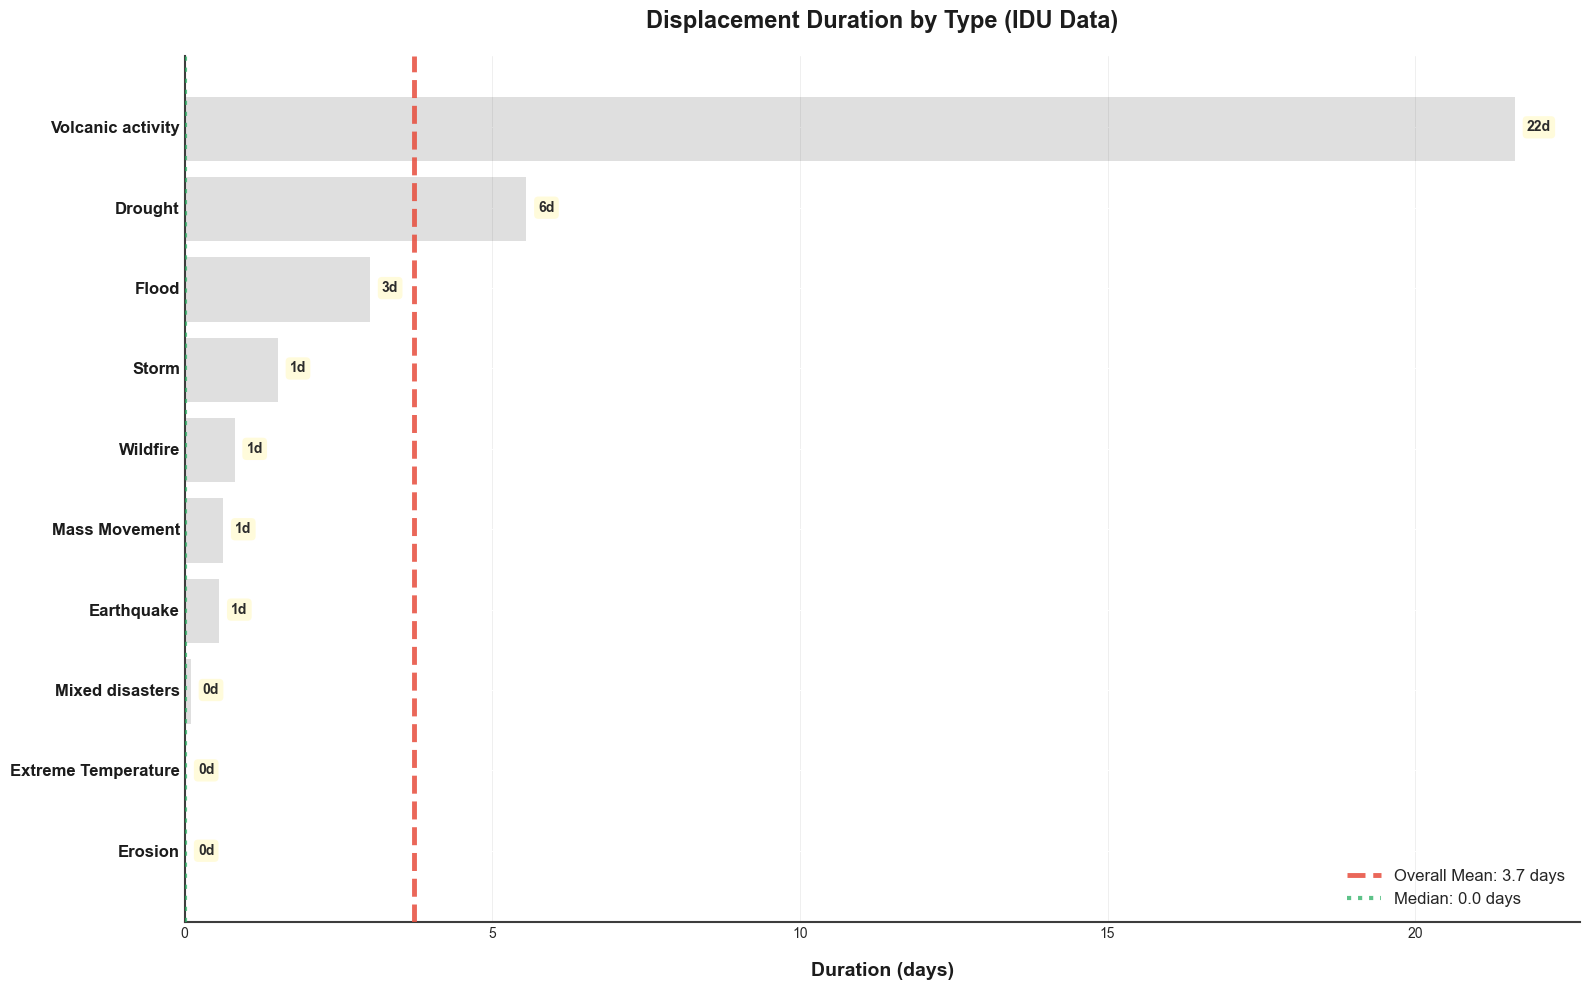

✓ IDU Duration plots saved:
  - Duration_by_Type_IDU_Enhanced.png (PNG, 300 DPI)
  - Duration_by_Type_IDU_Enhanced.pdf (PDF, 300 DPI)


In [22]:
# Create same plot for IDU data
# Calculate duration for IDU data
gdf_idu['duration_days'] = (gdf_idu['End date'] - gdf_idu['Start date']).dt.days

# Prepare IDU data
avg_by_type_idu = gdf_idu.groupby('type')['duration_days'].mean().sort_values(ascending=True)
overall_avg_idu = gdf_idu['duration_days'].mean()
median_val_idu = gdf_idu['duration_days'].median()

# Set up professional style with white background
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#FFFFFF'

# Create figure with clean layout
fig, ax1 = plt.subplots(figsize=(16, 10))

# Enhanced nature color palette with gradient (earth to forest)
nature_gradient = ['#D4A574', '#C99A6C', '#BE9064', '#B3865C', '#A87C54',
                   '#9D7250', '#926848', '#875E40', '#7C5438', '#714A30',
                   '#6A4126', '#63381D', '#5C3414', '#52300D', '#482C0B']

# Extend if needed
while len(nature_gradient) < len(avg_by_type_idu):
    nature_gradient.extend(nature_gradient)
colors = nature_gradient[:len(avg_by_type_idu)]

# ============== MAIN BAR PLOT ==============
bars = ax1.barh(range(len(avg_by_type_idu)), avg_by_type_idu.values, 
                 color=colors, edgecolor='#2C2C2C', linewidth=2, alpha=0.90)

# Add soft shadow effect to bars
for bar in bars:
    bar.set_path_effects([path_effects.SimplePatchShadow(offset=(1, -1), shadow_rgbFace='#2C2C2C', alpha=0.15)])

# Add overall average line with enhanced styling
ax1.axvline(overall_avg_idu, color='#E74C3C', linestyle='--', linewidth=3.5, 
            label=f'Overall Mean: {overall_avg_idu:.1f} days', zorder=5, alpha=0.85)
ax1.axvline(median_val_idu, color='#27AE60', linestyle=':', linewidth=3, 
            label=f'Median: {median_val_idu:.1f} days', zorder=4, alpha=0.75)

# Enhanced styling
ax1.set_yticks(range(len(avg_by_type_idu)))
ax1.set_yticklabels(avg_by_type_idu.index, fontsize=12, fontweight='600', color='#1C1C1C')
ax1.set_xlabel('Duration (days)', fontsize=14, fontweight='bold', color='#1C1C1C', labelpad=15)
ax1.set_title('Displacement Duration by Type (IDU Data)', 
              fontsize=17, fontweight='bold', color='#1C1C1C', pad=20, family='sans-serif')

# Grid styling
ax1.grid(axis='x', alpha=0.25, linestyle='-', linewidth=0.7, color='#BFBFBF')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#3D3D3D')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_color('#3D3D3D')
ax1.spines['bottom'].set_linewidth(1.5)

# Add value labels with better formatting
for i, (idx, val) in enumerate(avg_by_type_idu.items()):
    ax1.text(val + max(avg_by_type_idu.values) * 0.01, i, f'{val:.0f}d', 
             va='center', fontsize=10, fontweight='700', color='#2C2C2C',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFACD', alpha=0.7, edgecolor='none'))

# Enhanced legend
legend = ax1.legend(loc='lower right', fontsize=12, framealpha=0.95, 
                    edgecolor='#3D3D3D', fancybox=True, shadow=True)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()

# Save as both PNG and PDF with high quality
plt.savefig('../Duration_by_Type_IDU_Enhanced.png', dpi=300, bbox_inches='tight', 
            facecolor='#FFFFFF', edgecolor='none', format='png')
plt.savefig('../Duration_by_Type_IDU_Enhanced.pdf', dpi=300, bbox_inches='tight', 
            facecolor='#FFFFFF', edgecolor='none', format='pdf')
plt.show()

print("✓ IDU Duration plots saved:")
print("  - Duration_by_Type_IDU_Enhanced.png (PNG, 300 DPI)")
print("  - Duration_by_Type_IDU_Enhanced.pdf (PDF, 300 DPI)")

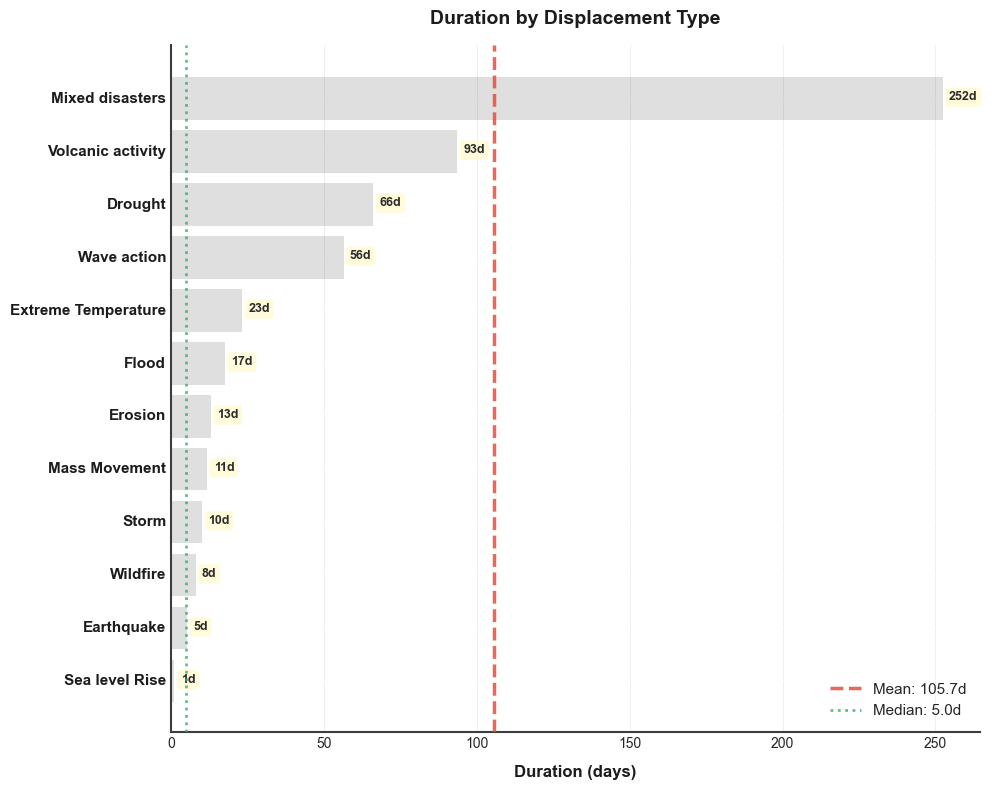

✓ Combined Duration plots saved:
  - Duration_by_Type_Combined_Enhanced.png (PNG, 300 DPI)
  - Duration_by_Type_Combined_Enhanced.pdf (PDF, 300 DPI)


In [25]:
# Combine both datasets (gdf and gdf_idu) and create unified plot
# Prepare combined data
# Use 'Hazard type' from gdf, rename to match gdf_idu's 'type' column for combining
gdf_combined_temp = gdf[['Hazard type', 'duration_days']].copy()
gdf_combined_temp.columns = ['type', 'duration_days']
gdf_idu_combined_temp = gdf_idu[['type', 'duration_days']].copy()

# Combine both dataframes
combined_data = pd.concat([gdf_combined_temp, gdf_idu_combined_temp], ignore_index=True)

# Calculate average duration by type
avg_by_type_combined = combined_data.groupby('type')['duration_days'].mean().sort_values(ascending=True)
overall_avg_combined = combined_data['duration_days'].mean()
median_val_combined = combined_data['duration_days'].median()

# Set up professional style with white background
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#FFFFFF'

# Create figure - half page size
fig, ax1 = plt.subplots(figsize=(10, 8))

# Enhanced nature color palette with gradient (earth to forest)
nature_gradient = ['#D4A574', '#C99A6C', '#BE9064', '#B3865C', '#A87C54',
                   '#9D7250', '#926848', '#875E40', '#7C5438', '#714A30',
                   '#6A4126', '#63381D', '#5C3414', '#52300D', '#482C0B']

# Extend if needed
while len(nature_gradient) < len(avg_by_type_combined):
    nature_gradient.extend(nature_gradient)
colors = nature_gradient[:len(avg_by_type_combined)]

# ============== MAIN BAR PLOT ==============
bars = ax1.barh(range(len(avg_by_type_combined)), avg_by_type_combined.values, 
                 color=colors, edgecolor='#2C2C2C', linewidth=1.5, alpha=0.90)

# Add soft shadow effect to bars
for bar in bars:
    bar.set_path_effects([path_effects.SimplePatchShadow(offset=(1, -1), shadow_rgbFace='#2C2C2C', alpha=0.15)])

# Add overall average line with enhanced styling
ax1.axvline(overall_avg_combined, color='#E74C3C', linestyle='--', linewidth=2.5, 
            label=f'Mean: {overall_avg_combined:.1f}d', zorder=5, alpha=0.85)
ax1.axvline(median_val_combined, color='#27AE60', linestyle=':', linewidth=2, 
            label=f'Median: {median_val_combined:.1f}d', zorder=4, alpha=0.75)

# Enhanced styling
ax1.set_yticks(range(len(avg_by_type_combined)))
ax1.set_yticklabels(avg_by_type_combined.index, fontsize=11, fontweight='600', color='#1C1C1C')
ax1.set_xlabel('Duration (days)', fontsize=12, fontweight='bold', color='#1C1C1C', labelpad=10)
ax1.set_title('Duration by Displacement Type', 
              fontsize=14, fontweight='bold', color='#1C1C1C', pad=15, family='sans-serif')

# Grid styling
ax1.grid(axis='x', alpha=0.25, linestyle='-', linewidth=0.7, color='#BFBFBF')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#3D3D3D')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_color('#3D3D3D')
ax1.spines['bottom'].set_linewidth(1.5)

# Add value labels with better formatting
for i, (idx, val) in enumerate(avg_by_type_combined.items()):
    ax1.text(val + max(avg_by_type_combined.values) * 0.01, i, f'{val:.0f}d', 
             va='center', fontsize=9, fontweight='700', color='#2C2C2C',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFACD', alpha=0.7, edgecolor='none'))

# Enhanced legend
legend = ax1.legend(loc='lower right', fontsize=11, framealpha=0.95, 
                    edgecolor='#3D3D3D', fancybox=True, shadow=True)
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()

# Save as both PNG and PDF with high quality
plt.savefig('../Duration_by_Type_Combined_Enhanced.png', dpi=300, bbox_inches='tight', 
            facecolor='#FFFFFF', edgecolor='none', format='png')
plt.savefig('../Duration_by_Type_Combined_Enhanced.pdf', dpi=300, bbox_inches='tight', 
            facecolor='#FFFFFF', edgecolor='none', format='pdf')
plt.show()

print("✓ Combined Duration plots saved:")
print("  - Duration_by_Type_Combined_Enhanced.png (PNG, 300 DPI)")
print("  - Duration_by_Type_Combined_Enhanced.pdf (PDF, 300 DPI)")